# Imports

In [1]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import matplotlib.cm as cm
from scipy.signal import convolve2d, hilbert
from scipy.ndimage import gaussian_filter
from PIL import Image

# Classification

In [2]:
def load_ct_scan(file):
    ct_scan = nib.load(file)
    ct_data = ct_scan.get_fdata()
    return ct_data

SEG_DIR = "data/s0344/segmentations"
files   = os.listdir(SEG_DIR)

ALL_LABELS = [f.replace(".nii.gz", "") for f in files]

def contains_any(name, keywords):
    return any(k in name for k in keywords)

BONE_LABELS         = [f for f in ALL_LABELS if contains_any(f, ["rib", "vertebra", "skull", "femur", "humerus", "clavicula", "scapula", "sacrum", "sternum", "hip"])]
MUSCLE_LABELS       = [f for f in ALL_LABELS if contains_any(f, ["muscle", "gluteus", "iliopsoas"])]
ORGAN_LABELS        = [f for f in ALL_LABELS if contains_any(f, ["liver", "kidney", "heart", "pancreas", "spleen", "prostate", "thyroid"])]
HOLLOW_ORGAN_LABELS = [f for f in ALL_LABELS if contains_any(f, ["stomach", "bowel", "colon", "bladder", "duodenum", "lung"])]
SOFT_TISSUE_LABELS  = [f for f in ALL_LABELS if contains_any(f, ["artery", "vena", "vein", "aorta", "cava", "trunk"])]

ct    = load_ct_scan("data/s0344/ct.nii.gz")
shape = ct.shape
print(shape)

(283, 283, 384)


## Helpers

In [3]:
def get_slice(vol, axis, idx, k=-1):
    """
    Choose axis: 0 (sagittal), 1 (coronal), 2 (axial)
    idx: index presjeka
    """
    if axis == 0:
        sl = vol[idx, :, :]
    elif axis == 1:
        sl = vol[:, idx, :]
    elif axis == 2:
        sl = vol[:, :, idx]
    else:
        raise ValueError("axis must be 0,1,2")

    sl = np.flipud(np.rot90(sl, k=k))
    return sl

def load_and_or(mask, name):
    path = os.path.join(SEG_DIR, name + ".nii.gz")
    if os.path.exists(path):
        return mask | (nib.load(path).get_fdata() > 0)
    return mask

## 3-D tissue masks

In [4]:
bone_mask   = np.zeros(shape, dtype=bool)
muscle_mask = np.zeros(shape, dtype=bool)
soft_mask   = np.zeros(shape, dtype=bool)
organ_mask  = np.zeros(shape, dtype=bool)
hollow_mask = np.zeros(shape, dtype=bool)

for label in BONE_LABELS:
    bone_mask = load_and_or(bone_mask, label)
for label in MUSCLE_LABELS:
    muscle_mask = load_and_or(muscle_mask, label)
for label in ORGAN_LABELS:
    organ_mask = load_and_or(organ_mask, label)
for label in HOLLOW_ORGAN_LABELS:
    hollow_mask = load_and_or(hollow_mask, label)
for label in SOFT_TISSUE_LABELS:
    soft_mask = load_and_or(soft_mask, label)

fat_mask = (ct >= -190) & (ct <= -30)

## Attenuation map

In [5]:
coronal_axis = 1
coronal_idx  = shape[coronal_axis] // 2

ct_cor = get_slice(ct, coronal_axis, coronal_idx)
bone   = get_slice(bone_mask,   coronal_axis, coronal_idx)
muscle = get_slice(muscle_mask, coronal_axis, coronal_idx)
organ  = get_slice(organ_mask,  coronal_axis, coronal_idx)
hollow = get_slice(hollow_mask, coronal_axis, coronal_idx)
soft   = get_slice(soft_mask,   coronal_axis, coronal_idx)
fat    = get_slice(fat_mask,    coronal_axis, coronal_idx)

organ  = organ  & ~bone
hollow = hollow & ~bone  & ~organ
muscle = muscle & ~bone  & ~organ & ~hollow
soft   = soft   & ~bone  & ~organ & ~hollow & ~muscle
fat    = fat    & ~bone  & ~organ & ~hollow & ~muscle & ~soft


In [6]:
def build_attenuation_map(masks, Z_background, Z_values):
    bone, organ, hollow, muscle, soft, fat = (masks[k] for k in ["bone", "organ", "hollow", "muscle", "soft", "fat"])

    Z = np.full(bone.shape, Z_background, dtype=np.float32)
    Z[hollow] = Z_values["hollow"]
    Z[fat]    = Z_values["fat"]
    Z[soft]   = Z_values["soft"]
    Z[organ]  = Z_values["organ"]
    Z[muscle] = Z_values["muscle"]
    Z[bone]   = Z_values["bone"] 
    # original value for bone impedance is 5.0 but for axial simulatin purpose it is increases because of the contrast

    Z_blur = gaussian_filter(Z, sigma=2.2)
    noise  = np.zeros_like(Z_blur)
    noise[fat]    = np.random.rayleigh(scale=0.02,  size=fat.sum())
    noise[muscle] = np.random.rayleigh(scale=0.03,  size=muscle.sum())
    noise[organ]  = np.random.rayleigh(scale=0.04,  size=organ.sum())
    noise[soft]   = np.random.rayleigh(scale=0.02,  size=soft.sum())
    noise[bone]   = np.random.rayleigh(scale=0.06,  size=bone.sum())
    noise[hollow] = np.random.rayleigh(scale=0.005, size=hollow.sum())

    Z_noisy = Z_blur * (1 + noise)

    plt.imshow(Z, cmap="gray")
    plt.title("Attenuation map - without noise")
    plt.show()

    return Z_noisy

## Segmentation

In [7]:
def get_segmentation(bone, organ, hollow, muscle, soft, fat):

    tissue_colors = ["black", "purple", "blue", "cyan", "green", "lightgreen", "yellow"]
    cmap_seg = ListedColormap(tissue_colors)

    seg = np.zeros(bone.shape, dtype=np.uint8)
    for val, m in enumerate([fat, soft, muscle, organ, hollow, bone], start=1):
        seg[m] = val

    plt.imshow(seg, cmap=cmap_seg)
    plt.title("Segmentation")
    plt.legend(handles=[
        mpatches.Patch(color="black",      label="Air/background"),
        mpatches.Patch(color="purple",     label="Fat"),
        mpatches.Patch(color="blue",       label="Soft tissue"),
        mpatches.Patch(color="cyan",       label="Muscle"),
        mpatches.Patch(color="green",      label="Organs"),
        mpatches.Patch(color="lightgreen", label="Hollow organs"),
        mpatches.Patch(color="yellow",     label="Bone"),
    ], loc="lower right", fontsize=8)
    plt.show()

## Organ labels

In [26]:
def plot_organs(ct_slice, labels, seg_dir, axis, idx, title="Organs", cmap=cm.tab20):

    organ_slices = {}
    for label in labels:
        path = os.path.join(seg_dir, label + ".nii.gz")
        if os.path.exists(path):
            mask = get_slice(nib.load(path).get_fdata() > 0, axis, idx)
            if mask.sum() > 100:
                organ_slices[label] = mask

    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(ct_slice, cmap="gray", vmin=-200, vmax=300)

    colors   = cmap(np.linspace(0, 1, len(organ_slices)))
    patches  = []

    for color, (label, mask) in zip(colors, organ_slices.items()):
        overlay       = np.zeros((*mask.shape, 4))
        overlay[mask] = [*color[:3], 0.5]
        ax.imshow(overlay)

        ys, xs = np.where(mask)
        cx, cy = int(xs.mean()), int(ys.mean())
        name   = label.replace("_", " ").split()[0]
        ax.text(cx, cy, name, color="white", fontsize=12,
                ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.2", facecolor=color[:3], alpha=0.7))
        patches.append(Patch(facecolor=color[:3], label=name))

    ax.legend(handles=patches, loc="lower right", fontsize=12, ncol=2, framealpha=0.8)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

# Coronal plots

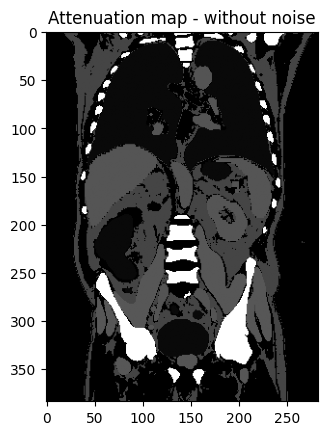

In [9]:
Z_cor_values = dict(hollow=0.18, fat=1.35, soft=1.65, organ=1.67, muscle=1.70, bone=5.0)
Z_cor_noisy = build_attenuation_map({"bone": bone, "organ": organ, "hollow": hollow, "muscle": muscle, "soft": soft, "fat": fat}, Z_background=0.0, Z_values=Z_cor_values)

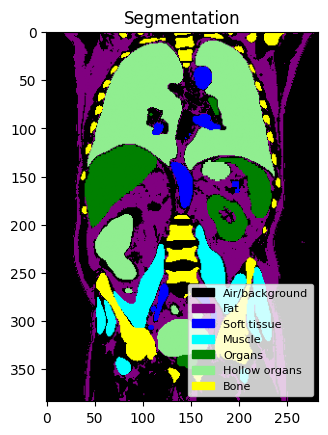

In [10]:
get_segmentation(bone, organ, hollow, muscle, soft, fat)

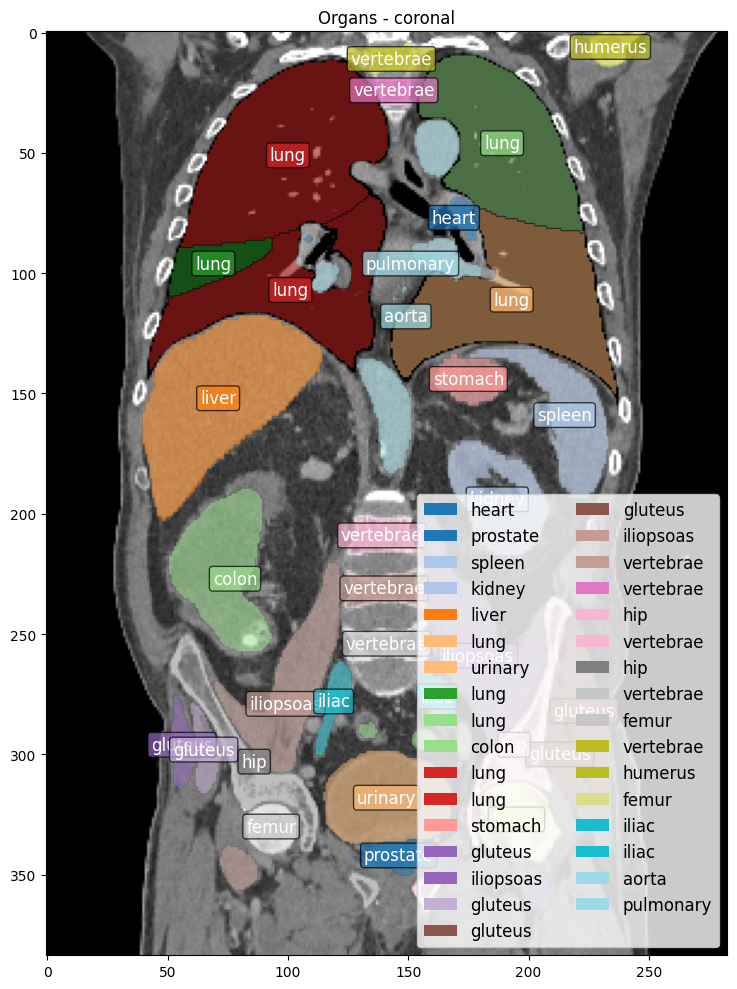

In [27]:
plot_organs(ct_cor, ORGAN_LABELS + HOLLOW_ORGAN_LABELS + MUSCLE_LABELS + BONE_LABELS + SOFT_TISSUE_LABELS, SEG_DIR, axis=1, idx=coronal_idx, title="Organs - coronal", cmap=cm.tab20)

# Axial plots

In [15]:
axial_axis = 2

axial_idx = int(shape[2] * 0.65)

ct_ax = get_slice(ct, axial_axis,axial_idx)
bone_ax   = get_slice(bone_mask,   axial_axis, axial_idx)
muscle_ax = get_slice(muscle_mask, axial_axis, axial_idx)
organ_ax  = get_slice(organ_mask,  axial_axis, axial_idx)
hollow_ax = get_slice(hollow_mask, axial_axis, axial_idx)
soft_ax   = get_slice(soft_mask,   axial_axis, axial_idx)
fat_ax    = get_slice(fat_mask,    axial_axis, axial_idx)

# Priority masking
organ_ax  = organ_ax  & ~bone_ax
hollow_ax = hollow_ax & ~bone_ax  & ~organ_ax
muscle_ax = muscle_ax & ~bone_ax  & ~organ_ax & ~hollow_ax
soft_ax   = soft_ax   & ~bone_ax  & ~organ_ax & ~hollow_ax & ~muscle_ax
fat_ax    = fat_ax    & ~bone_ax  & ~organ_ax & ~hollow_ax & ~muscle_ax & ~soft_ax

# Resize to 2048×2048
new_h, new_w = 2048, 2048

def resize_mask(mask, h, w):
    return np.array(
        Image.fromarray(mask.astype(np.uint8)).resize((w, h), resample=Image.NEAREST)).astype(bool)

bone_ax   = resize_mask(bone_ax,   new_h, new_w)
muscle_ax = resize_mask(muscle_ax, new_h, new_w)
organ_ax  = resize_mask(organ_ax,  new_h, new_w)
hollow_ax = resize_mask(hollow_ax, new_h, new_w)
soft_ax   = resize_mask(soft_ax,   new_h, new_w)
fat_ax    = resize_mask(fat_ax,    new_h, new_w)


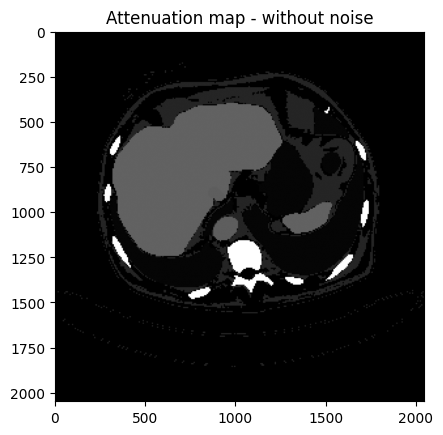

In [16]:
Z_ax_values = dict(hollow=1.18, fat=1.35, soft=1.65, organ=1.67, muscle=1.70, bone=2.5)
Z_noisy = build_attenuation_map({"bone": bone_ax, "organ": organ_ax, "hollow": hollow_ax, "muscle": muscle_ax, "soft": soft_ax, "fat": fat_ax}, Z_background=1.15, Z_values=Z_ax_values)

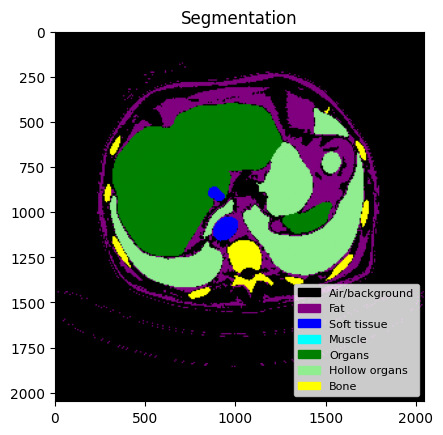

In [17]:
get_segmentation(bone_ax, organ_ax, hollow_ax, muscle_ax, soft_ax, fat_ax)

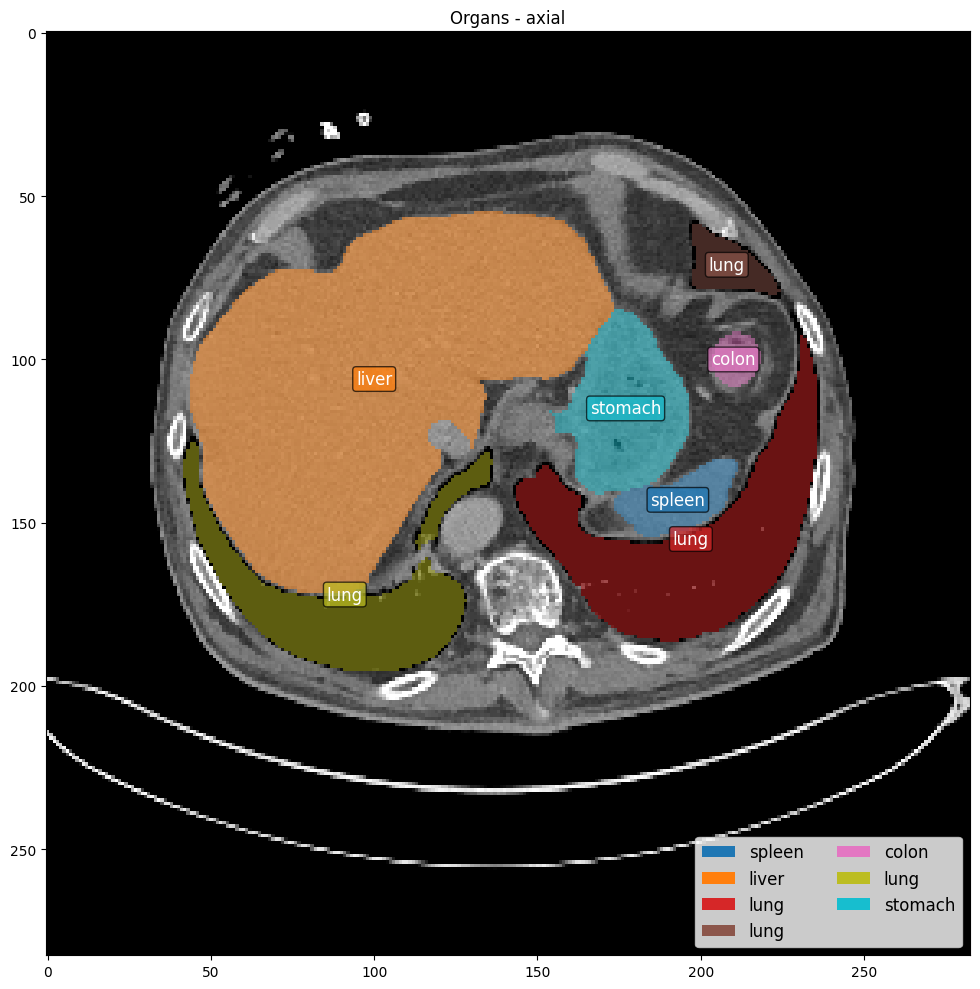

In [28]:
plot_organs(ct_ax, ORGAN_LABELS + HOLLOW_ORGAN_LABELS, SEG_DIR, axis=2, idx=axial_idx, title="Organs - axial", cmap=cm.tab10)

# PSF, transformations → B-mode

In [20]:
def create_Bmode(sigma_ax=3.5, sigma_lat=32, f=3.5, plot=False):   
    x = np.linspace(-128, 128, 128)
    y = np.linspace(-128, 128, 128)
    xx, yy = np.meshgrid(x, y)

    PSF = (np.exp(-0.5 * (yy**2 / sigma_ax**2 + xx**2 / sigma_lat**2)))*np.cos(2*np.pi*f*yy)

    T = np.gradient(np.gradient(Z_noisy, axis=0), axis=0)
    RF = convolve2d(T, PSF, mode='same') 

    # Envelope detection
    envelope = np.abs(hilbert(RF, axis=0))

    # Log compression 
    eps = 1e-6
    dynamic_range = 40
    bmode = 20 * np.log10(envelope / (envelope.max() + eps) + eps)
    bmode = np.clip(bmode, -dynamic_range, 0)
    bmode_norm = (bmode + dynamic_range) / dynamic_range

    if plot:
        plt.figure(figsize=(15, 5))

        plt.subplot(1, 3, 1)
        plt.imshow(PSF)
        plt.title("PSF")

        plt.subplot(1, 3, 2)
        plt.imshow(envelope, cmap='gray')
        plt.title("Envelope")

        plt.subplot(1, 3, 3)
        plt.imshow(bmode_norm, cmap='gray')
        plt.title("B-mode")

        plt.show()


    return bmode_norm

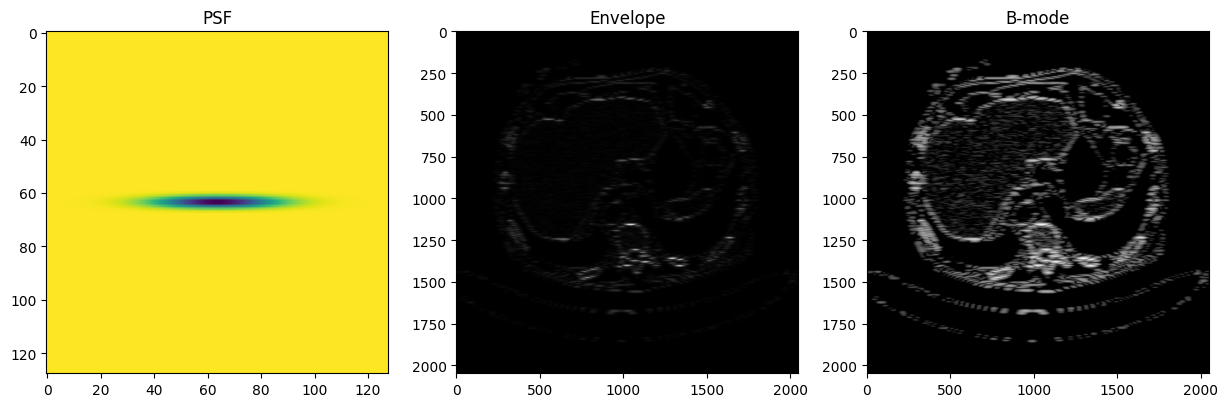

In [21]:
bmode = create_Bmode(plot=True)

## Sector mask

In [29]:
def apply_sector_mask(bmode_crop, angle=80):
    h, w   = bmode_crop.shape
    cy, cx = 0, w // 2
    mask   = np.zeros((h, w), dtype=bool)
    for i in range(h):
        for j in range(w):
            dx, dy = j - cx, i - cy
            ang    = np.degrees(np.arctan2(dx, dy))
            dist   = np.sqrt(dx**2 + dy**2)
            if abs(ang) < angle / 2 and dist < h:
                mask[i, j] = True
    bmode_crop[~mask] = 0
    plt.imshow(bmode_crop, cmap="gray")
    plt.title("B-mode")
    plt.show()
    return bmode_crop

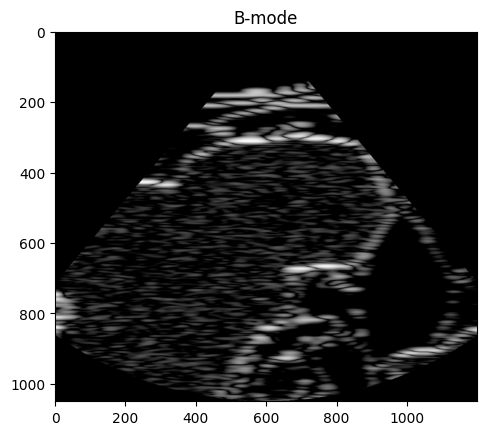

In [30]:
bmode_crop = apply_sector_mask(bmode[100:1150, 300:1500].copy(), angle=80)

# Parameter change

## Pulse frequency

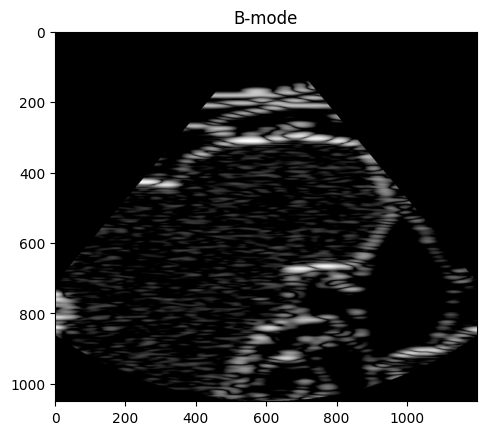

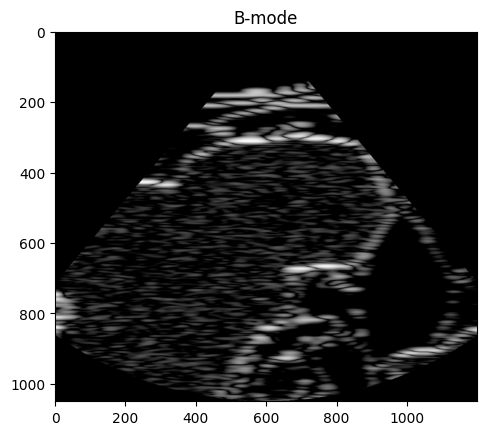

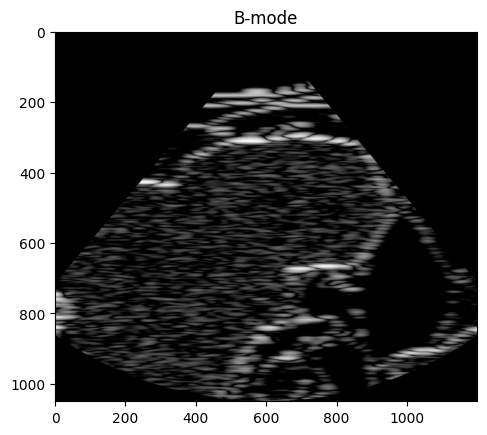

In [31]:
pulse_freqs = [1, 3.5, 5]
for freq in pulse_freqs:
    bmode      = create_Bmode(f=freq)
    bmode_crop = apply_sector_mask(bmode[100:1150, 300:1500].copy(), angle=80)

## Number of elements (lateral resolution)

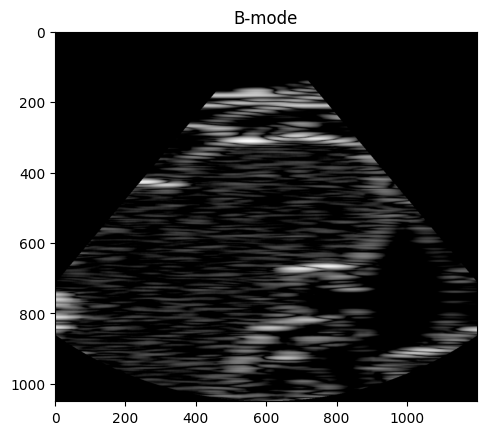

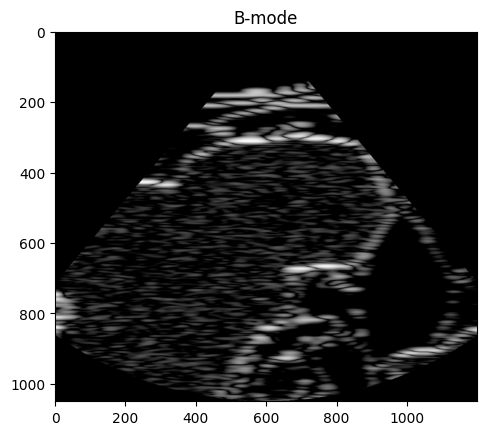

In [32]:
num_elements = [64, 128]
for num in num_elements:
    sigma_lat  = 32 * (128 / num)
    bmode      = create_Bmode(sigma_lat=sigma_lat)
    bmode_crop = apply_sector_mask(bmode[100:1150, 300:1500].copy(), angle=80)